In [25]:
import os
import rasterio as rio
import numpy as np
import pandas as pd


from spectral import envi
import matplotlib.pyplot as plt
import matplotlib.path as mpth
from pathlib import Path

from scipy.ndimage import binary_erosion
from pyproj import Transformer

import shapefile as shp
import pickle as pk


import Functions
import importlib

importlib.reload(Functions)

<module 'Functions' from '/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/Functions/Functions.py'>

In [26]:
app_path = Functions.get_input_path() / 'App'
input_path = app_path / 'Data' / 'Ground_Campaign'

sentinel_path = Path('/media')/ 'frank' / 'USB' / 'SCUOLA' / 'App' / 'COHERENCIA'

shape_path = input_path / 'Flevoland_data' / 'Data_25_fields' / 'Flevoland-fields-Shapefiles' / 'Feloveland-fields-Shapefiles'

path: /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA


In [27]:
img_dates = Functions.read_dates_from_stack(sentinel_path)

shapes = list(shape_path.glob('*.shp'))
hdrs = list(sentinel_path.glob('*06days*.hdr'))

Estraggo i poligoni dei campi

In [28]:
mypoly = {}

for file in shapes:
    file_stem = Path(file).stem
    
    # 1. Load and Transform in one go
    # This now returns a list of dicts: [{'objectid': 1, 'coords': [...]}, ...]
    poly_data_list = Functions.open_shp_with_geopandas(file)

    if poly_data_list is not None:

        for feature in poly_data_list:
            obj_id = feature['objectid']
            utm_coords = feature['coords']
            tipo = feature['Type']                                
            
            # 3. Create Path objects for each part of the geometry
            # (Handling MultiPolygons by creating a list of Paths)
            paths = [mpth.Path(p) for p in utm_coords]
            
            mypoly[obj_id] = {
                'Name': file_stem,
                'id': obj_id,
                'coord': utm_coords,
                'path': paths,
                'Type': tipo
            }
            
            print(f"Successfully processed {file_stem} - {obj_id}.")
    else:
        print(f"Skipping file {file} because it is invalid or empty.")

print(f"Total files processed: {len(mypoly.keys())}")

Successfully processed DB_A_C - 1841224.
Successfully processed AKW_SB_C - 1936134.
An error occurred: Unable to open /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Data/Ground_Campaign/Flevoland_data/Data_25_fields/Flevoland-fields-Shapefiles/Feloveland-fields-Shapefiles/HF2-SB_C.shx or /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Data/Ground_Campaign/Flevoland_data/Data_25_fields/Flevoland-fields-Shapefiles/Feloveland-fields-Shapefiles/HF2-SB_C.SHX. Set SHAPE_RESTORE_SHX config option to YES to restore or create it.
Skipping file /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Data/Ground_Campaign/Flevoland_data/Data_25_fields/Flevoland-fields-Shapefiles/Feloveland-fields-Shapefiles/HF2-SB_C.shp because it is invalid or empty.
Successfully processed KL_MA_1_C - 2088262.
Successfully processed HF3_WT_C - 1576641.
Successfully processed PE_A4_C - 1889482.
Successfully processed SB7_ER_C - 1697689.
Successfully processed KL_MA2-C - 1896343.
Succes

Reading SAR geographical coordinates

In [29]:
X_geo, Y_geo = Functions.axes_from_metadata(hdrs[0])

for key in mypoly:

    # 1. Find the total Bounding Box by merging all field parts
    # Stack all pieces to calculate global min/max
    all_coords = np.vstack(mypoly[key]['coord'])
    xmin, ymin = all_coords.min(axis=0)
    xmax, ymax = all_coords.max(axis=0)

    # 2. Find indices within the Sentinel image
    idx_x = np.where((X_geo >= xmin) & (X_geo <= xmax))[0]
    idx_y = np.where((Y_geo >= ymin) & (Y_geo <= ymax))[0]

    # 3. Create the point grid for cropping (Subset)
    r0, r1 = idx_y.min(), idx_y.max() + 1
    c0, c1 = idx_x.min(), idx_x.max() + 1

    X_sub = X_geo[c0:c1]
    Y_sub = Y_geo[r0:r1]
    
    # 4. Improved mask creation
    X_grid, Y_grid = np.meshgrid(X_sub, Y_sub)
    # Important: use stack to get clean (x, y) pairs
    points = np.column_stack((X_grid.ravel(), Y_grid.ravel()))

    mymask_sub = np.zeros(X_grid.shape, dtype=bool)
    # Iterate over each Path object in the previously saved list
    for pth_obj in mypoly[key]['path']:
        # Create the mask for the single part and merge it using logical OR (|)
        # Use standard 'C' order and then .reshape()
        current_part_mask = pth_obj.contains_points(points).reshape(X_grid.shape)
        mymask_sub |= current_part_mask

    # Apply binary erosion to avoid edge effects
    mask_eroted = binary_erosion(mymask_sub, structure=np.ones((3,3))).astype(mymask_sub.dtype)
    mypoly[key]['mask_sub'] = mask_eroted # mymask_sub
    mypoly[key]['r_range'] = (r0, r1)
    mypoly[key]['c_range'] = (c0, c1)

# Final Debug
field = 1545384
print(f"Starting column index for {field}: {mypoly[field]['c_range'][0]}")
print(f"Eroded mask shape: {mypoly[field]['mask_sub'].shape}")

Starting column index for 1545384: 5374
Eroded mask shape: (24, 33)


In [30]:
#df = pd.DataFrame(mypoly).T
#display(df)
#df.to_csv(f'/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/polygons_geo.csv', index=True)

ReadingSAR images and saving the average and the std in a dictionary:
poly_stats[name_polygon][data+VV/VH][avg/std]

In [31]:
poly_stats = {k: {} for k in mypoly}

for file in hdrs:

    file_path = Path(file)
    file_stem = file_path.stem
    date = file_stem[:8] # Assumendo formato YYYYMMDD
    
    # 1. Apriamo il file (senza caricarlo in RAM!)
    img_obj = Functions.read_img2(file, '')

    # Determiniamo la polarizzazione dal nome del file
    pol = 'VH' if 'VH' in file_stem else 'VV'
    name = f'{date}_{pol}'

    print(f'Processing {pol} for date {date}...')

    for key in mypoly:
        r1, r2 = mypoly[key]['r_range']
        c1, c2 = mypoly[key]['c_range']
    
        # 2. LEGGIAMO SOLO IL RITAGLIO DAL DISCO
        # read_subregion( (r_start, r_end), (c_start, c_end) )
        radar_sub = img_obj.read_subregion((r1, r2), (c1, c2))
        
        # Pulizia dimensioni (da (H, W, 1) a (H, W))
        radar_sub = np.squeeze(radar_sub)
    
        # 3. Applichiamo la maschera erosa
        pixel_campo = radar_sub[mypoly[key]['mask_sub']]

        if len(pixel_campo) > 0:
            if name not in poly_stats[key]:
                poly_stats[key][name] = {}
            
            # Calcolo in lineare
            m_lin = np.mean(pixel_campo)
            s_lin = np.std(pixel_campo)
            
            # Salvataggio (puoi aggiungere anche la conversione in dB qui)
            poly_stats[key][name]['mean'] = m_lin
            poly_stats[key][name]['std'] = s_lin

        else:
            print(f"Attenzione: nessun pixel valido per {key} in {file_stem}")

# Pulizia manuale della memoria alla fine di ogni file (opzionale)

del img_obj

Processing VH for date 20170104...
Processing VV for date 20170104...
Processing VH for date 20170110...
Processing VV for date 20170110...
Processing VH for date 20170116...
Processing VV for date 20170116...
Processing VH for date 20170122...
Processing VV for date 20170122...
Processing VH for date 20170128...
Processing VV for date 20170128...
Processing VH for date 20170203...
Processing VV for date 20170203...
Processing VH for date 20170209...
Processing VV for date 20170209...
Processing VH for date 20170215...
Processing VV for date 20170215...
Processing VH for date 20170221...
Processing VV for date 20170221...
Processing VH for date 20170227...
Processing VV for date 20170227...
Processing VH for date 20170305...
Processing VV for date 20170305...
Processing VH for date 20170311...
Processing VV for date 20170311...
Processing VH for date 20170317...
Processing VV for date 20170317...
Processing VH for date 20170323...
Processing VV for date 20170323...
Processing VH for da

In [32]:
print(poly_stats.keys())

dict_keys([1841224, 1936134, 2088262, 1576641, 1889482, 1697689, 1896343, 2278835, 1601502, 1936133, 1824038, 1545384, 1553694, 2081268, 2081267, 2081887, 1697691, 1767881, 2294423, 1698168, 1889479, 1841223, 1936135, 2041694, 1697690, 1631664, 1841225])


In [33]:
print(poly_stats[1841224]['20170104_VH'])

{'mean': np.float32(0.846021), 'std': np.float32(0.060364123)}


In [34]:
Nme_types = pd.read_csv('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/areas_Flavoland.csv',
                         header=0)


SyntaxError: invalid syntax (358888346.py, line 1)

Dataframe with statistics

In [36]:
rows = []
for roi, dates_dict in poly_stats.items():
    for date_band, stats in dates_dict.items():
        row = {'Code': roi, 'Date_Band': date_band}
        row.update(stats) # Aggiunge 'mean', 'std', ecc. come colonne
        rows.append(row)

df_stats = pd.DataFrame(rows)

df_stats[['Date', 'Band']] = df_stats['Date_Band'].str.split('_', expand=True)
df_stats['Date'] = pd.to_datetime(df_stats['Date'])
df_stats = df_stats.merge(Nme_types[['Code','Name', 'Type']], on='Code', how='left')

display(df_stats)

,Code,Date_Band,mean,std,Date,Band,Name,Type
0,1841224,20170104_VH,0.846021,0.060364,2017-01-04,VH,DB_A_C,Aardappelen
1,1841224,20170104_VV,0.912519,0.032522,2017-01-04,VV,DB_A_C,Aardappelen
2,1841224,20170110_VH,0.470780,0.095106,2017-01-10,VH,DB_A_C,Aardappelen
3,1841224,20170110_VV,0.660484,0.081345,2017-01-10,VV,DB_A_C,Aardappelen
4,1841224,20170116_VH,0.311812,0.113724,2017-01-16,VH,DB_A_C,Aardappelen
...,...,...,...,...,...,...,...,...
3019,1841225,20171212_VV,0.191203,0.106592,2017-12-12,VV,DB_SB1_C,Bieten
3020,1841225,20171218_VH,0.916552,0.026221,2017-12-18,VH,DB_SB1_C,Bieten
3021,1841225,20171218_VV,0.957047,0.016386,2017-12-18,VV,DB_SB1_C,Bieten
3022,1841225,20171224_VH,0.895575,0.024988,2017-12-24,VH,DB_SB1_C,Bieten


Visualizing the mask of a polygon and the mean value

0.9356459


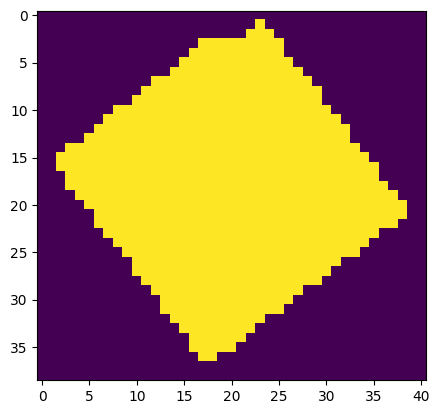

In [37]:
print(poly_stats[1936133]['20170305_VV']['mean'])
plt.imshow(mypoly[1936133]['mask_sub'])

(6346, 7025)



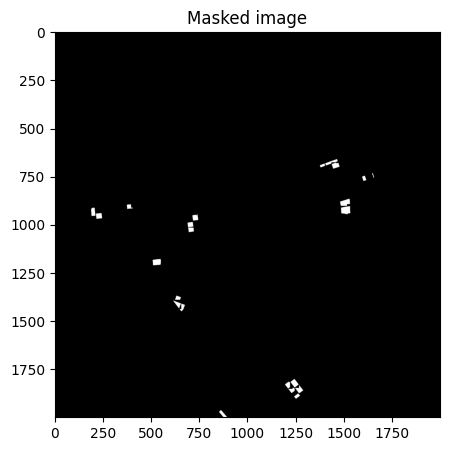

In [38]:
full_mask = np.zeros((len(Y_geo), len(X_geo)), dtype=bool)
print(full_mask.shape)

_, IMG = Functions.read_img(hdrs[0],'')

# 2. Inserisci la maschera piccola nella posizione corretta usando gli indici
# idx_y e idx_x definiscono le "coordinate matriciali" in cui incollare il pezzo
print()
for i in mypoly:

    full_mask[mypoly[i]['r_range'][0]:mypoly[i]['r_range'][1], 
              mypoly[i]['c_range'][0]:mypoly[i]['c_range'][1]] = mypoly[i]['mask_sub']

plt.figure(figsize=(5,5))
plt.imshow(full_mask[1000:3000,4000:6000], cmap='gray')
plt.title("Masked image")
plt.show()

Uploading the file with the rain time series
(#https://sensoto.io/en/data/?c=5.518613%2C52.454220&z=10.03&te=2017-01-01T00%3A00%3A00.000Z%2C2017-12-31T23%3A59%3A59.999Z&tz=B&sid=open%24ghcn-hourly%24fru77206001%24precipitation%2Copen%24ghcn%24nle00152489%24prcp%2Copen%24ghcn%24nle00109000%24prcp&v=chart)

In [39]:
df_rainfall = pd.read_parquet(r'/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/rainfall_total.parquet')
df_rainfall.index = pd.to_datetime(df_rainfall.index, format='%Y-%m-%d')

Check when is the first date of the SAR data

In [40]:
prima_corrispondenza = next((d for d in df_rainfall.index if np.datetime64(d) == img_dates[0]), None)

print(f"Data trovata: {prima_corrispondenza}")

Data trovata: 2017-01-04 00:00:00


In [41]:
df_filtered = df_rainfall.loc[prima_corrispondenza:]
print(df_filtered)

            prec_mm
date               
2017-01-04      4.3
2017-01-05      0.1
2017-01-06      5.9
2017-01-07      2.1
2017-01-08      0.2
...             ...
2018-01-08      0.0
2018-01-09      0.0
2018-01-10      2.9
2018-01-11      0.3
2018-01-12      0.6

[374 rows x 1 columns]


Weekly resampling (every 6 days)

In [42]:
df_weekly = df_filtered.resample('6D', label='left').sum()

GRAFICI DELLE STATISTICHE

In [43]:
from matplotlib.backends.backend_pdf import PdfPages
# 1. Trasformazione del dizionario in DataFrame (Formato Lungo)
# Definisci il nome del file di uscita

output_folder = app_path / 'Documents'
output_folder.mkdir(parents=True, exist_ok=True)

pdf_filename = output_folder / 'Time_Series_ROI_Coherence1.pdf'

with PdfPages(pdf_filename) as pdf:
    unique_rois = df_stats['Code'].unique()

    for (roi, roi_type, crop), group in df_stats.groupby(['Code', 'Name', 'Type']):
        # 1. Prepariamo la figura e gli assi
        fig, ax1 = plt.subplots(figsize=(12, 6))
        
        # Filtriamo i dati ROI
        roi_data = df_stats[df_stats['Code'] == roi]
        
        
        # --- SICUREZZA DATE ---
        # Filtriamo le piogge per mostrare solo lo stesso periodo della coerenza
        min_date = roi_data['Date'].min()
        max_date = roi_data['Date'].max()
        rain_filtered = df_weekly[(df_weekly.index >= min_date) & (df_weekly.index <= max_date)]

        # --- ASSE 2: PIOGGIA (Sotto le linee) ---
        ax2 = ax1.twinx()
        # Usiamo zorder=1 per metterlo sullo sfondo
        ax2.bar(rain_filtered.index, rain_filtered.iloc[:,0], 
                color='skyblue', alpha=0.3, label='Rainfall (mm)', width=0.8, zorder=1)
        
        ax2.set_ylabel("Rainfall (mm)", color='tab:blue', fontsize=12, fontweight='bold')
        ax2.tick_params(axis='y', labelcolor='tab:blue')
        
        # Spazio sopra le barre per non coprire le linee (regola il moltiplicatore se serve)
        if not rain_filtered.empty and rain_filtered.iloc[:,0].max() > 0:
            ax2.set_ylim(0, rain_filtered.iloc[:,0].max() * 2.5)
        ax2.invert_yaxis() 

        # --- ASSE 1: COERENZA (Sopra le barre) ---
        # Portiamo ax1 davanti a ax2
        ax1.set_zorder(ax2.get_zorder() + 1)
        ax1.patch.set_visible(False) # Rende ax1 trasparente per vedere ax2 sotto
        
        for band in roi_data['Band'].unique():
            band_data = roi_data[roi_data['Band'] == band]
            line, = ax1.plot(band_data['Date'], band_data['mean'], 
                             marker='o', markersize=4, linestyle='-', linewidth=2, 
                             label=f'Mean {band}', zorder=3)
            
            ax1.fill_between(
                band_data['Date'], 
                band_data['mean'] - band_data['std'], 
                band_data['mean'] + band_data['std'], 
                color=line.get_color(), 
                alpha=0.1, zorder=2
            )

        ax1.set_ylabel("Coherence", fontsize=12, fontweight='bold')
        ax1.set_xlabel("Data", fontsize=12)
        ax1.set_ylim(0, 1.1) # La coerenza di solito sta tra 0 e 1

        # --- LEGENDA E LAYOUT ---
        # Uniamo le labels di entrambi gli assi
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        
        # Spostiamo la legenda leggermente più a destra e usiamo subplots_adjust
        ax1.legend(h1 + h2, l1 + l2, loc='upper left', bbox_to_anchor=(1.08, 1), borderaxespad=0.)

        plt.title(f"ROI: {roi} ({roi_type} - {crop})- Coherence vs Rainfall", fontsize=14, pad=20)
        ax1.grid(True, linestyle='--', alpha=0.4)
        
        # Ruotiamo le date sull'asse X
        plt.setp(ax1.get_xticklabels(), rotation=45)
        
        # Invece di tight_layout puro, usiamo margin per far spazio alla legenda
        plt.subplots_adjust(right=0.85, bottom=0.15)
        
        pdf.savefig(fig)
        plt.close(fig)